# Saving processed data into a clean file

Saves all the ranging distance data into a csv file in the form of a table.


In [1]:
import os
import pandas as pd
import re
from glob import glob

def extract_column_label(filename):
    match = re.search(r'\(0, *(\d+)\)', filename)
    return match.group(1) if match else None

def collect_columns_by_file(folder_path, output_csv="distance_matrix.csv"):
    files = glob(os.path.join(folder_path, "serial_data_*.csv"))

    data_dict = {}

    for file in files:
        try:
            label = extract_column_label(os.path.basename(file))
            if label is None:
                print(f"Unrecognized format: {file}")
                continue

            df = pd.read_csv(file, header=None,
                             names=["Timestamp", "Distance", "Tag EUI", "Anchor EUI", "Est_X", "Est_Y"],
                             dtype=str)
            
        
            df = df[pd.to_numeric(df["Distance"], errors="coerce").notnull()]
            df["Distance"] = df["Distance"].astype(float)

            if label in data_dict:
                data_dict[label].extend(df["Distance"].tolist())
            else:
                data_dict[label] = df["Distance"].tolist()

        except Exception as e:
            print(f"Error reading {file}: {e}")

    if not data_dict:
        print("No valid distance data found.")
        return

    
    max_len = max(len(col) for col in data_dict.values())
    for key in data_dict:
        data_dict[key] += [None] * (max_len - len(data_dict[key]))

    result_df = pd.DataFrame(data_dict)
    result_df = result_df[sorted(result_df.columns, key=lambda x: int(x))]

    result_df.to_csv(output_csv, index=False)
    print(f"Saved as: {output_csv}")


if __name__ == "__main__":
    folder = r"C:\Users\Judy\Desktop\safmc_uwb\simulate_localization\0805_ranging_test_result(no distance modified)"
    collect_columns_by_file(folder)


Unrecognized format: C:\Users\Judy\Desktop\safmc_uwb\simulate_localization\0805_ranging_test_result(no distance modified)\serial_data_(0,xx)_20250805_195608.csv
Saved as: distance_matrix.csv


# See the shape of the distribution

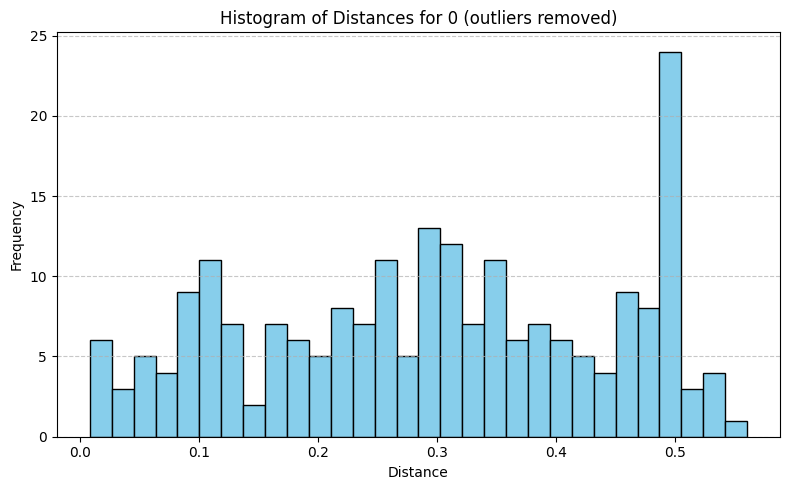

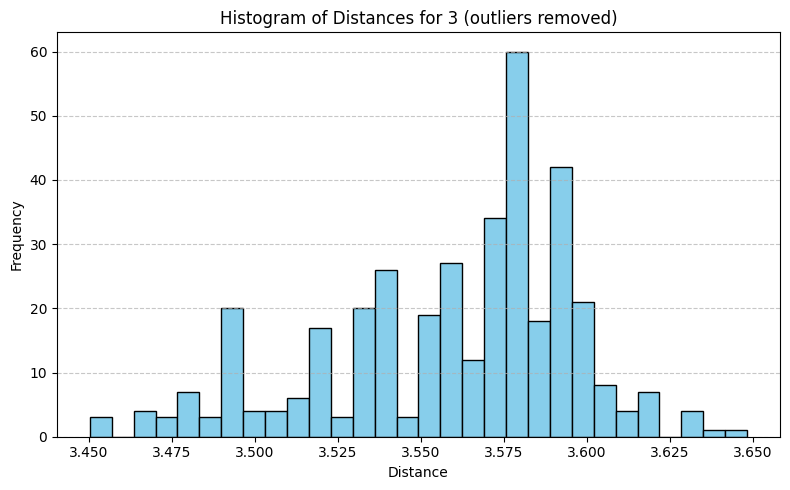

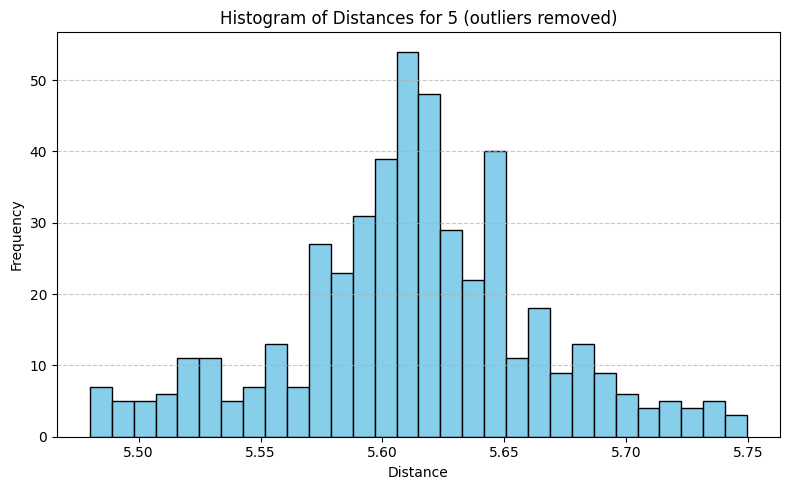

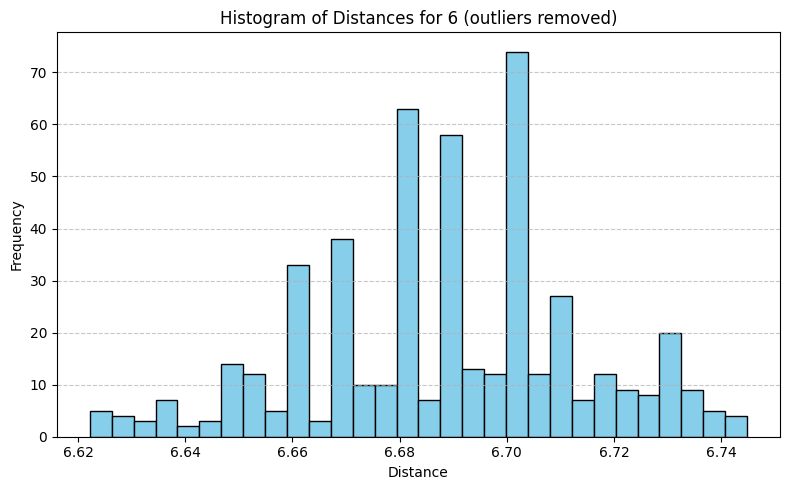

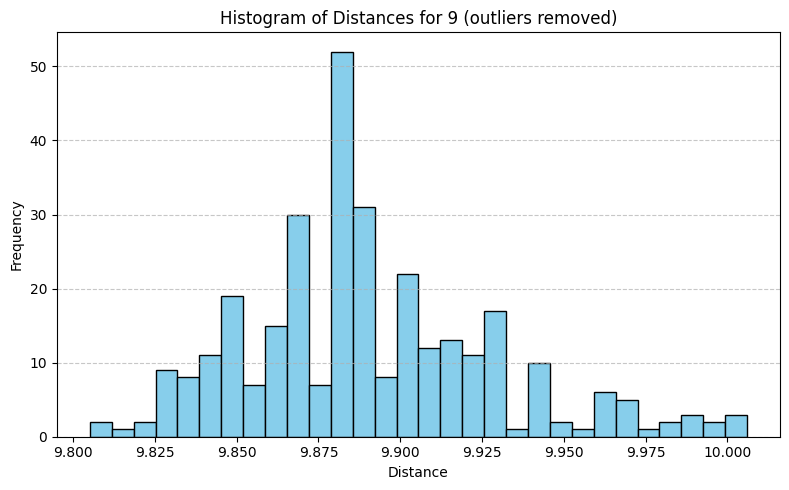

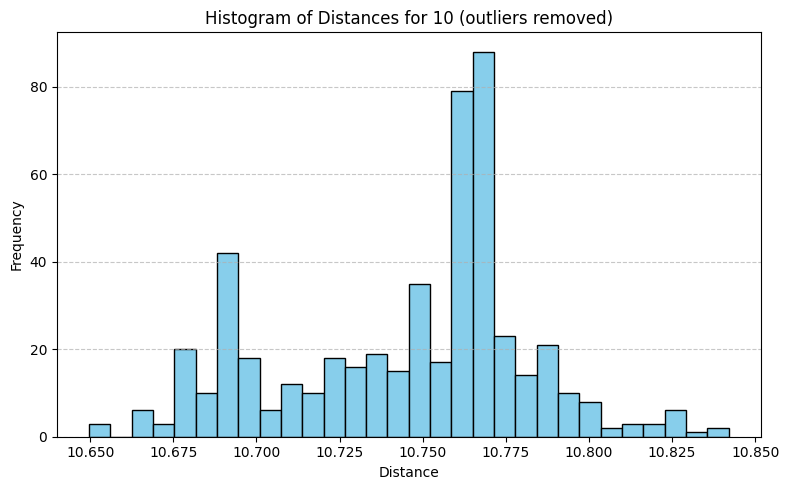

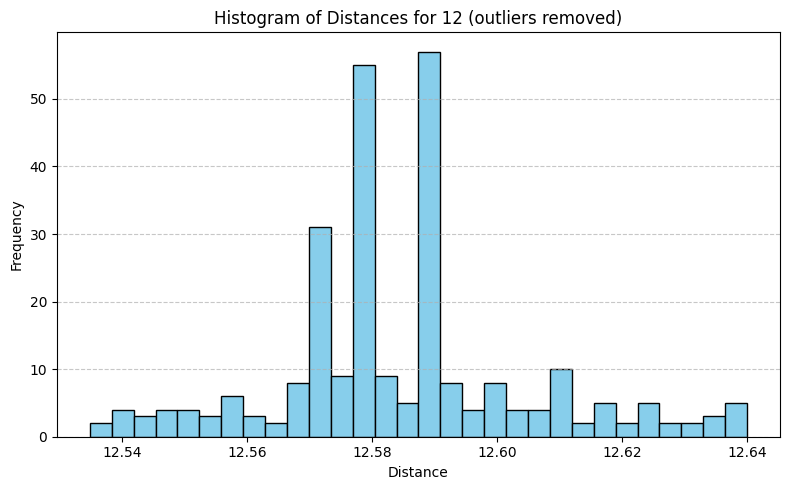

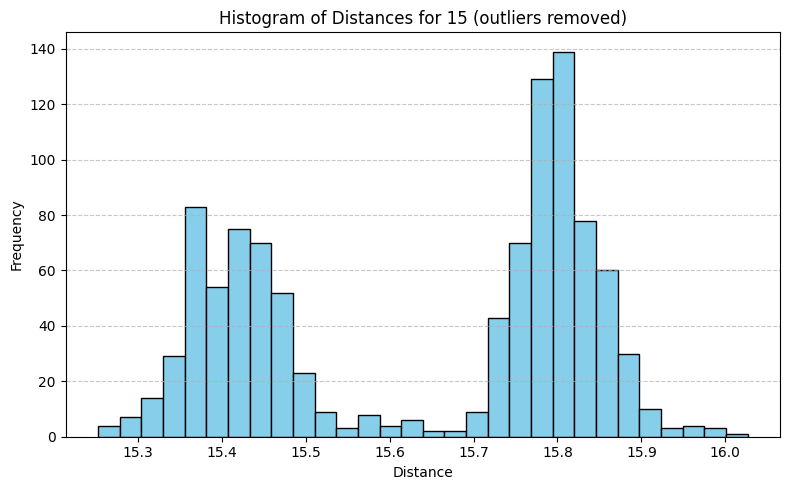

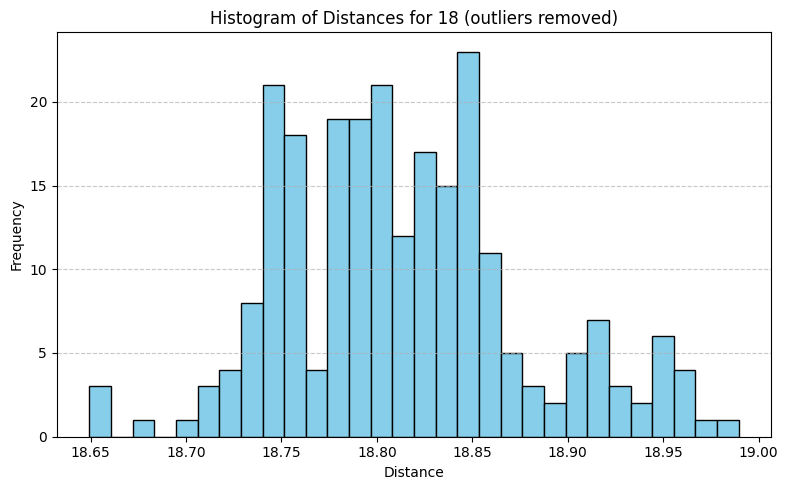

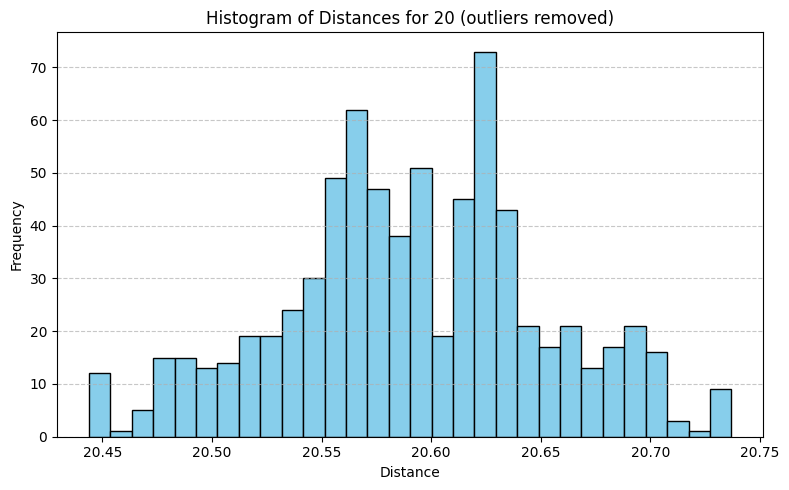

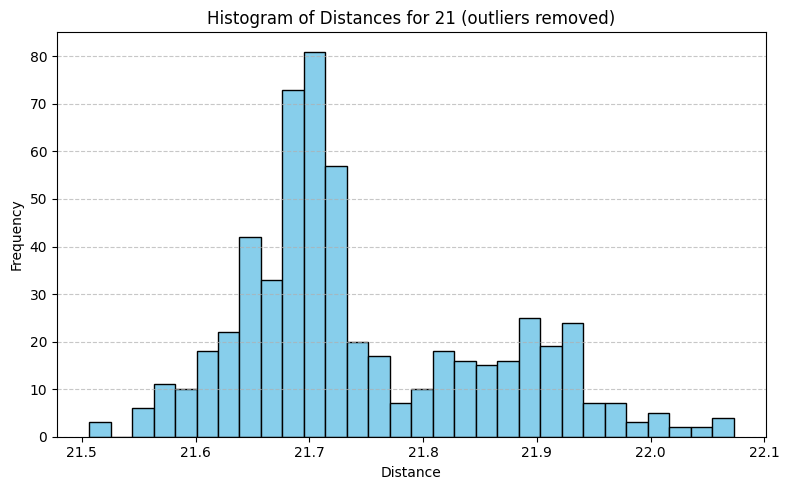

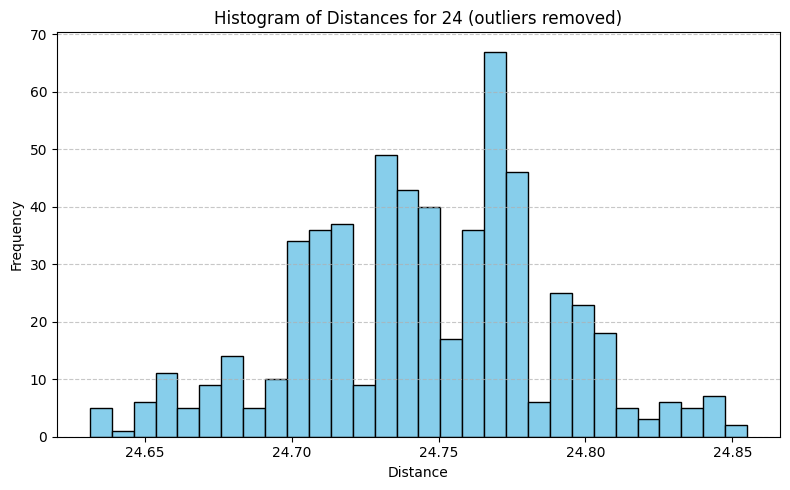

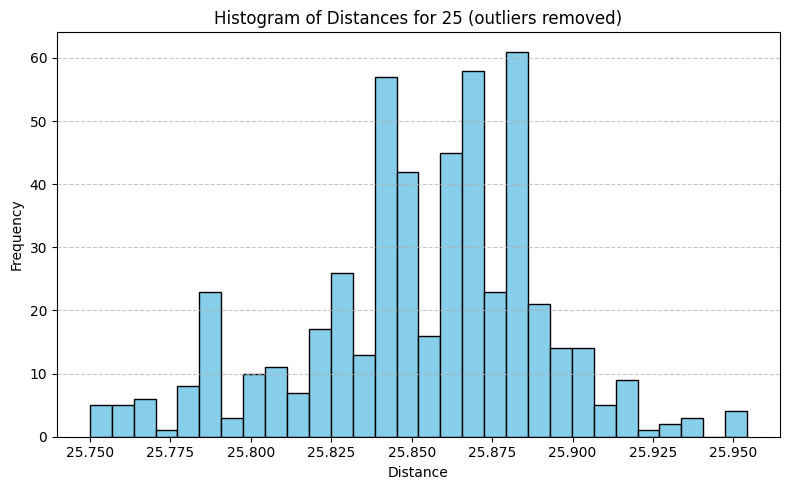

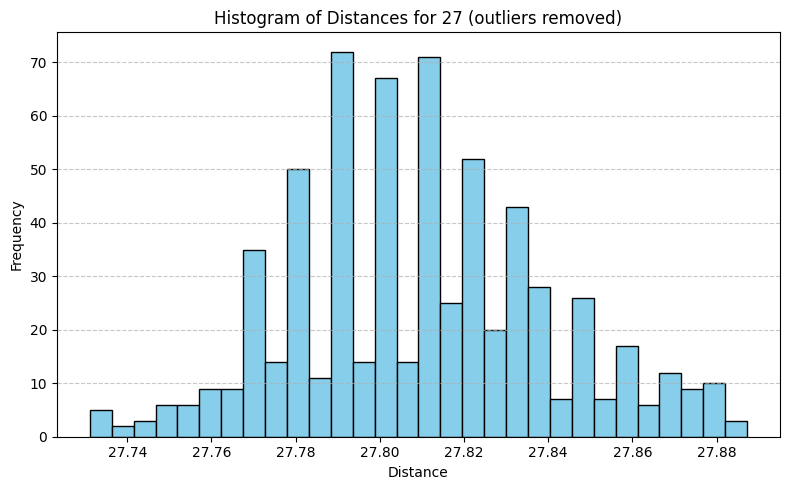

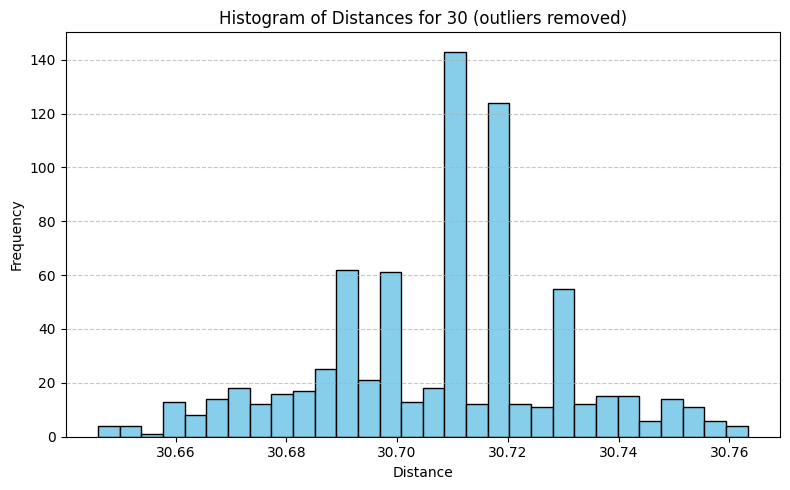

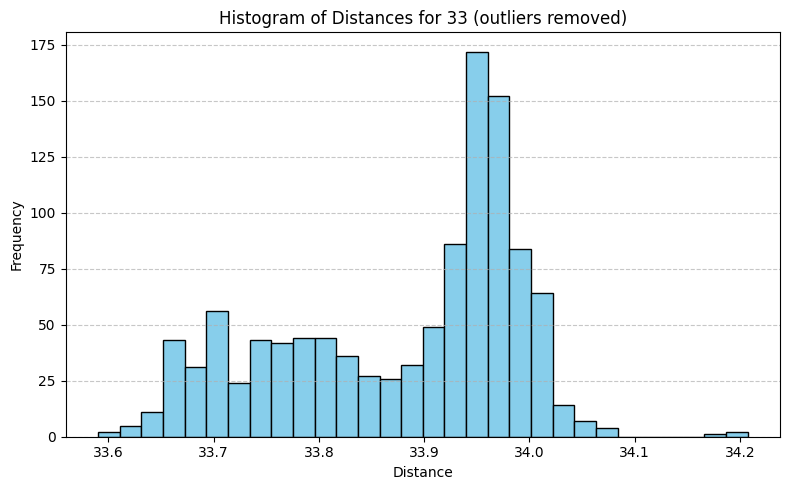

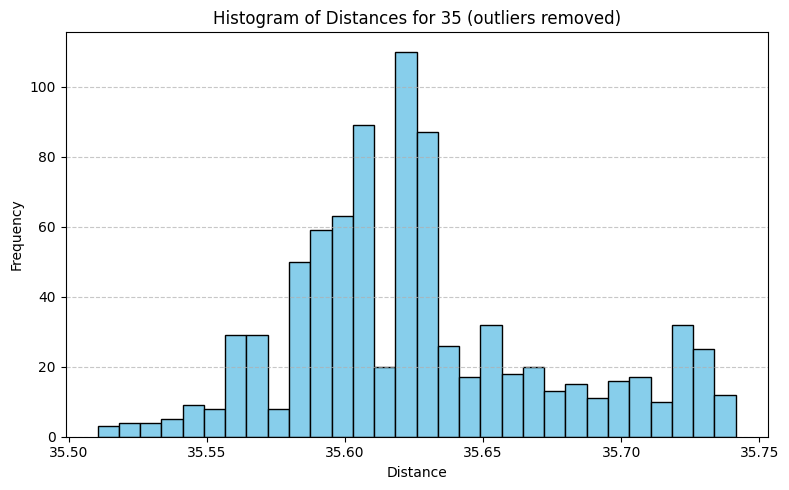

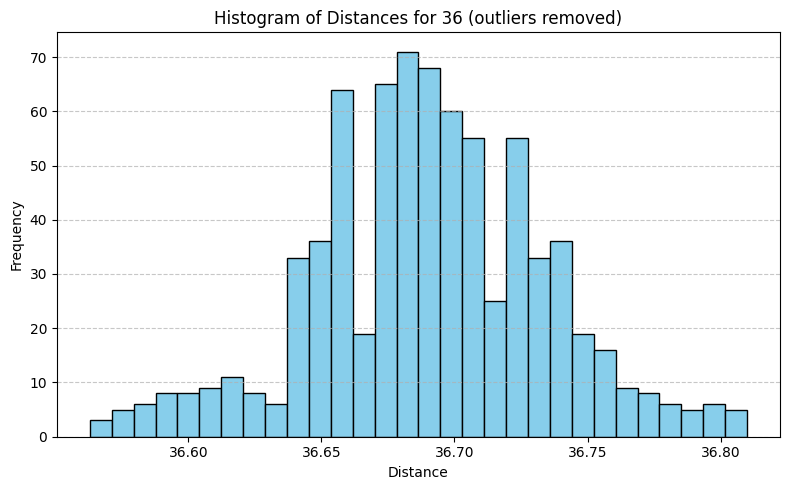

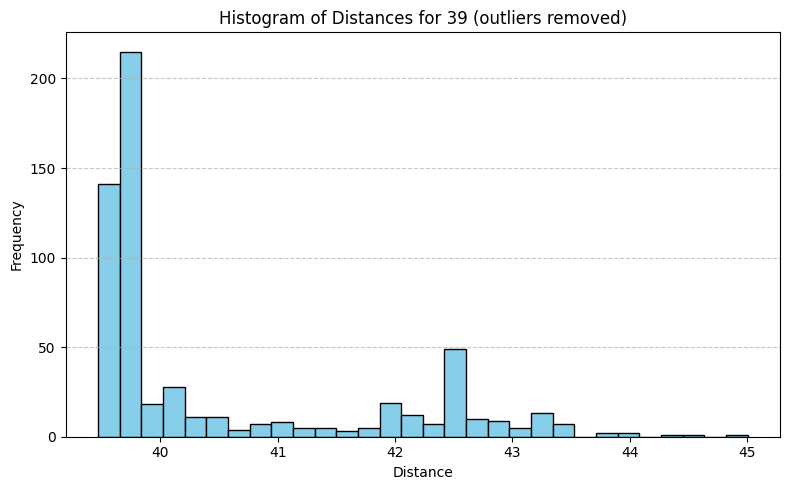

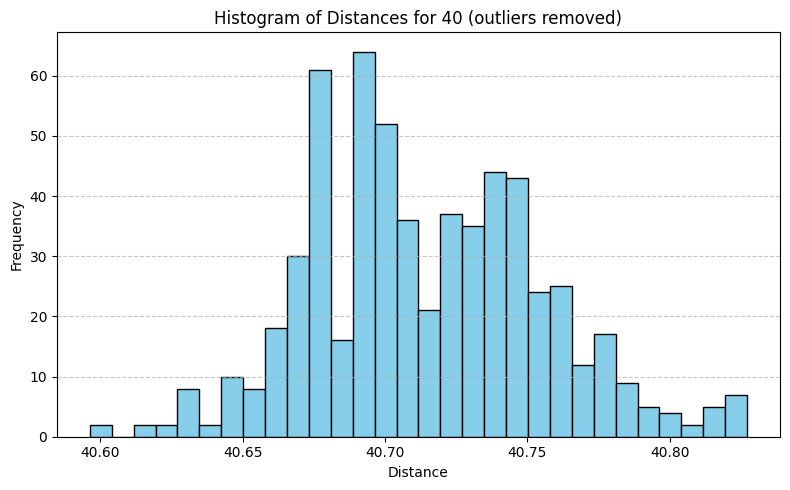

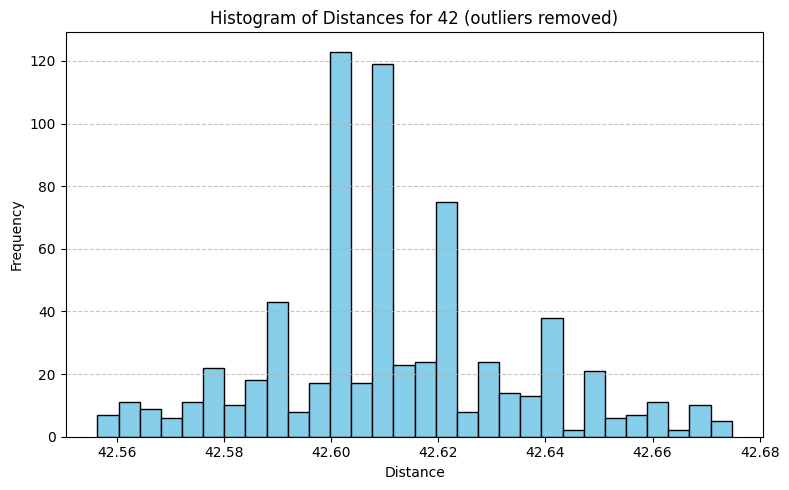

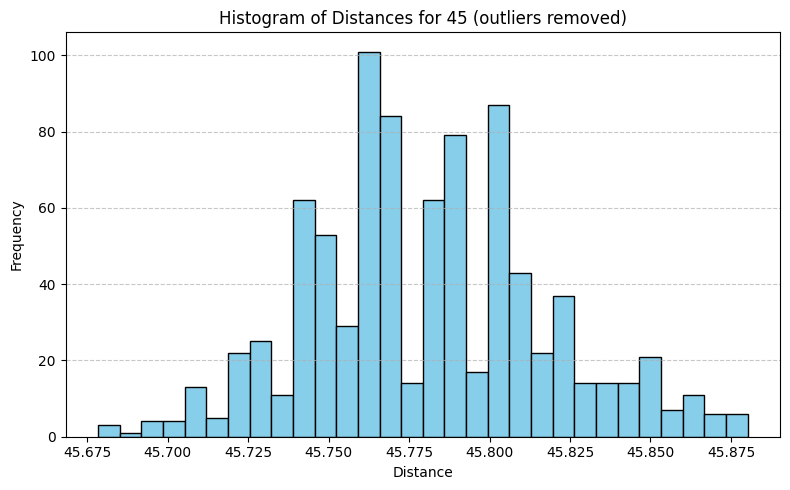

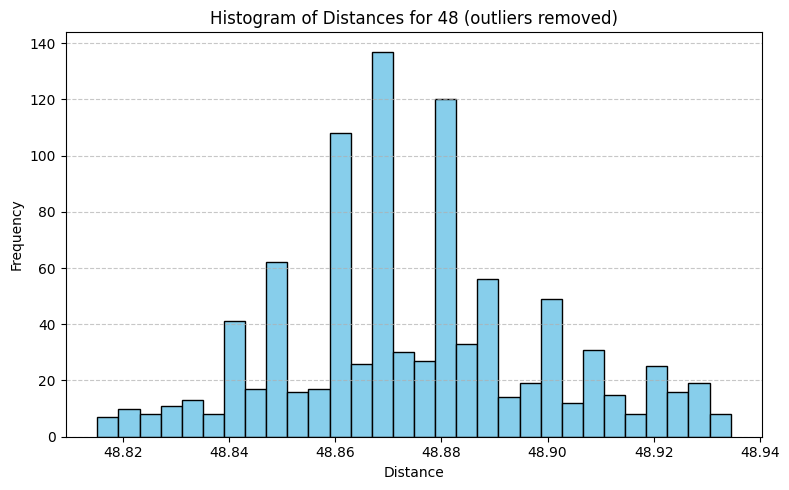

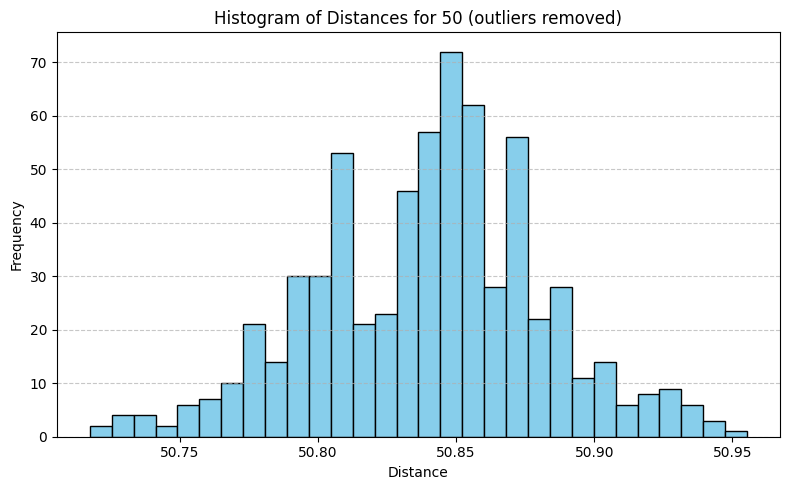

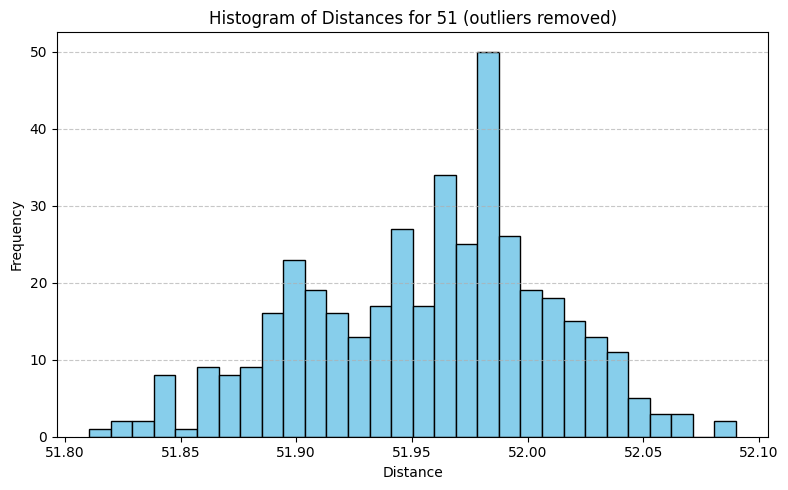

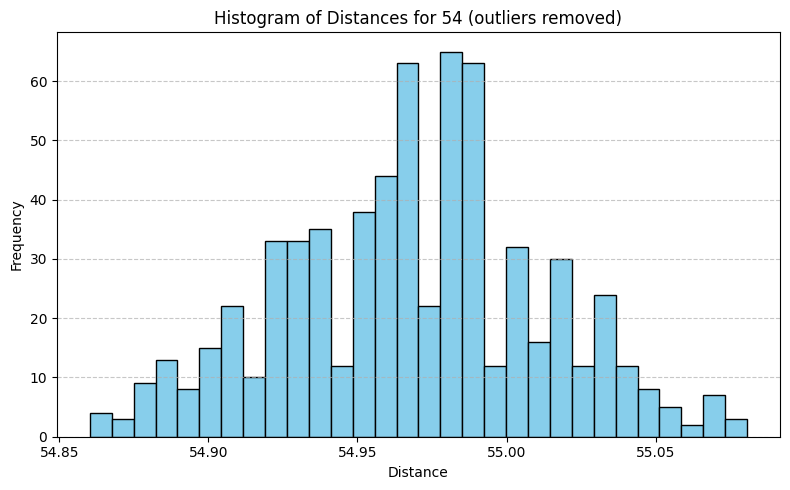

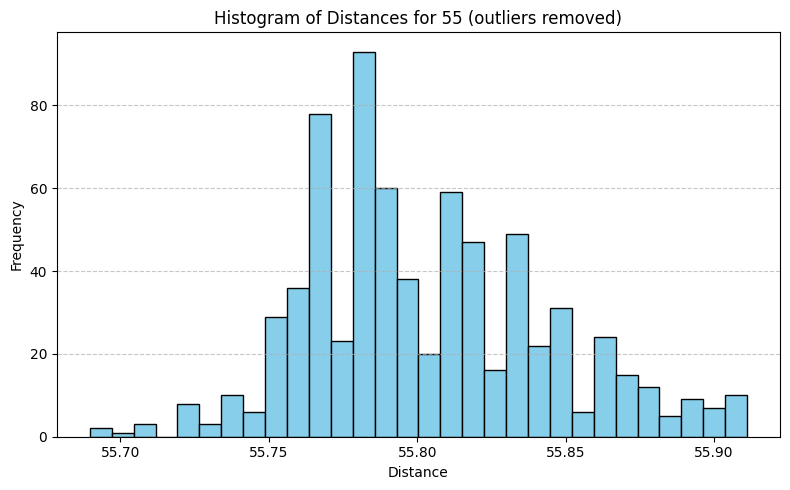

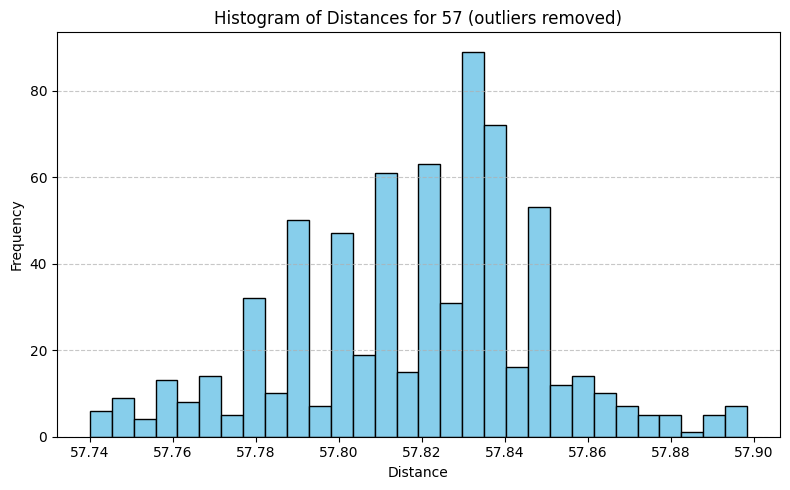

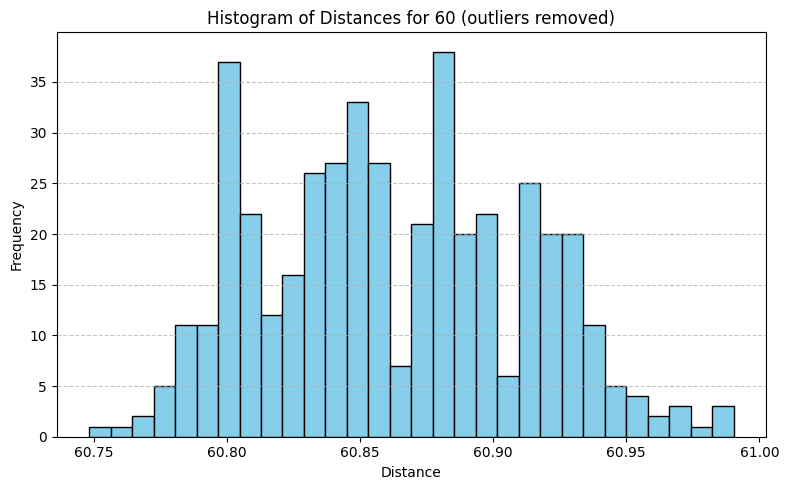

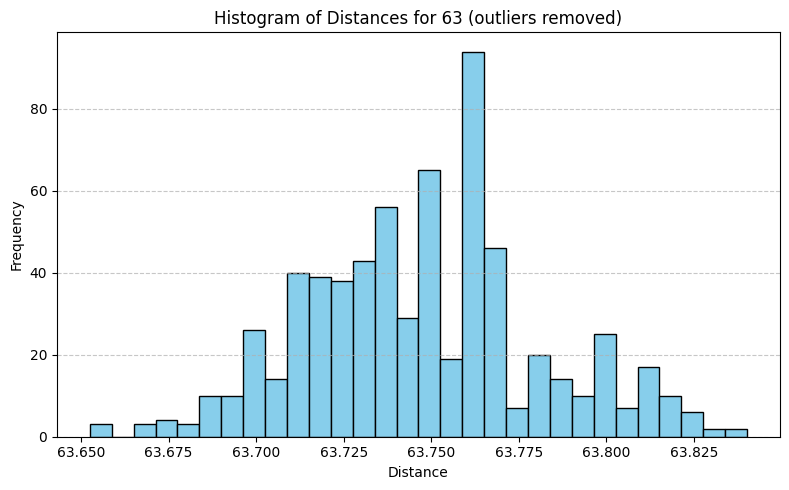

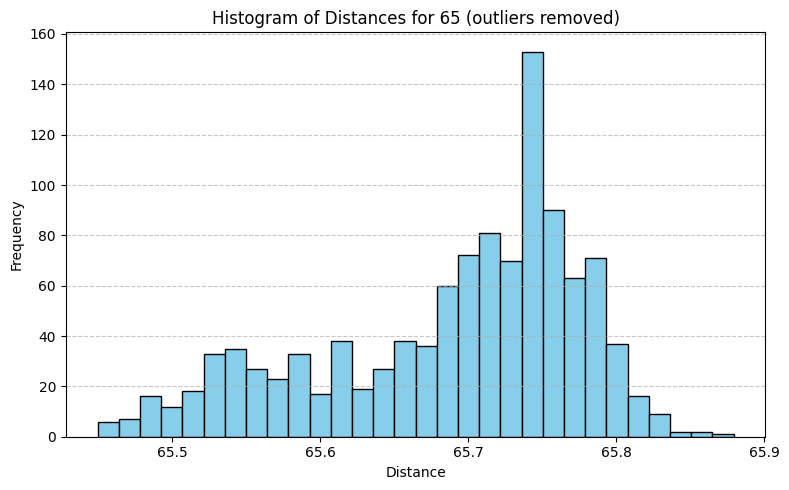

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def remove_outliers_iqr(series):
    """Remove outliers outside 1.5*IQR range."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series >= lower_bound) & (series <= upper_bound)]

def plot_histograms_separately_no_outliers(input_csv="distance_matrix.csv", output_folder="histograms_no_outliers", bins=30):
    df = pd.read_csv(input_csv)
    os.makedirs(output_folder, exist_ok=True)

    for col in df.columns:
        data = df[col].dropna()
        data_filtered = remove_outliers_iqr(data)

        plt.figure(figsize=(8,5))
        plt.hist(data_filtered, bins=bins, color='skyblue', edgecolor='black')
        plt.title(f"Histogram of Distances for {col} (outliers removed)")
        plt.xlabel('Distance')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        plt.show()
        # Optional: save plot
        # plt.savefig(os.path.join(output_folder, f"histogram_{col}_no_outliers.png"))
        # plt.close()

if __name__ == "__main__":
    plot_histograms_separately_no_outliers()


Standard deviation saved to: distance_std.csv
   Real Length       Mean  Standard Deviation
0            0   0.295330            0.148242
1            3   3.555320            0.043708
2            5   5.611584            0.078889
3            6   6.687916            0.030269
4            9   9.907520            0.068376
5           10  10.758531            0.075397
6           12  12.597979            0.053864
7           15  15.638884            0.198789
8           18  18.828468            0.084648
9           20  20.589397            0.065091
10          21  21.747853            0.123263
11          24  24.744993            0.044865
12          25  25.845751            0.052680
13          27  27.813871            0.040793
14          30  30.704179            0.036058
15          33  33.905523            0.284102
16          35  35.627905            0.054037
17          36  36.719465            0.816694
18          39  40.702720            1.557951
19          40  40.725437         

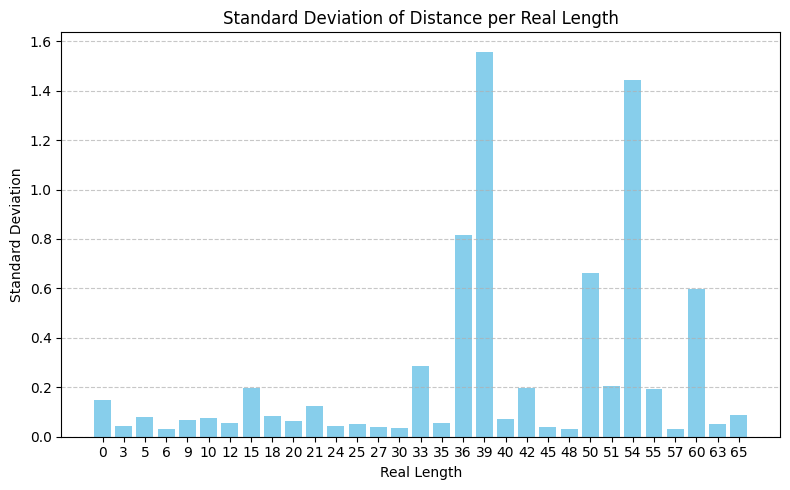

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_std(input_csv="distance_matrix.csv", output_csv="distance_std.csv"):
    df = pd.read_csv(input_csv)
    
    std_series = df.std(skipna=True)
    mean_series = df.mean(skipna=True)

    std_df = pd.DataFrame({
        'Real Length': std_series.index,
        'Mean': mean_series.values,
        'Standard Deviation': std_series.values
    })

    std_df.to_csv(output_csv, index=False)
    print(f"Standard deviation saved to: {output_csv}")

    print(std_df)
    
    plt.figure(figsize=(8,5))
    plt.bar(std_df['Real Length'], std_df['Standard Deviation'], color='skyblue')
    plt.xlabel('Real Length')
    plt.ylabel('Standard Deviation')
    plt.title('Standard Deviation of Distance per Real Length')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    calculate_std()


# Regression formula

回歸公式: TrueDistance = 0.9964 * MeasuredDistance + -0.6446


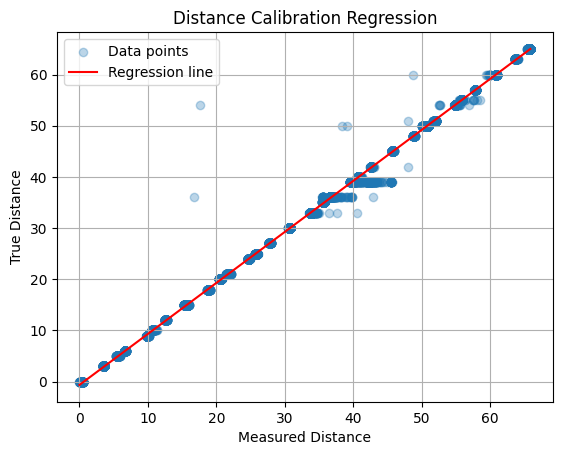

In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# 讀取 CSV
df = pd.read_csv("distance_matrix.csv")

# 轉換成長格式(long format)
long_df = df.melt(var_name="TrueDistance", value_name="MeasuredDistance")

# 刪除 NaN
long_df = long_df.dropna()

# 轉換型態
long_df["TrueDistance"] = long_df["TrueDistance"].astype(float)
long_df["MeasuredDistance"] = long_df["MeasuredDistance"].astype(float)

# 準備回歸資料
X = long_df["MeasuredDistance"].values.reshape(-1, 1)  # 測量值 (自變數)
y = long_df["TrueDistance"].values                      # 真實距離 (目標值)

# 線性回歸擬合
model = LinearRegression()
model.fit(X, y)

a = model.coef_[0]
b = model.intercept_
print(f"回歸公式: TrueDistance = {a:.4f} * MeasuredDistance + {b:.4f}")

# 可視化散點與回歸線
plt.scatter(X, y, alpha=0.3, label="Data points")
x_fit = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_fit = model.predict(x_fit)
plt.plot(x_fit, y_fit, color='red', label="Regression line")
plt.xlabel("Measured Distance")
plt.ylabel("True Distance")
plt.title("Distance Calibration Regression")
plt.legend()
plt.grid(True)
plt.show()


# simulate with 三角定位

✅ Total points: 600
📊 Mean error     = 1.1114 m
📈 Max error      = 8.9581 m
📉 Std deviation  = 0.8851 m


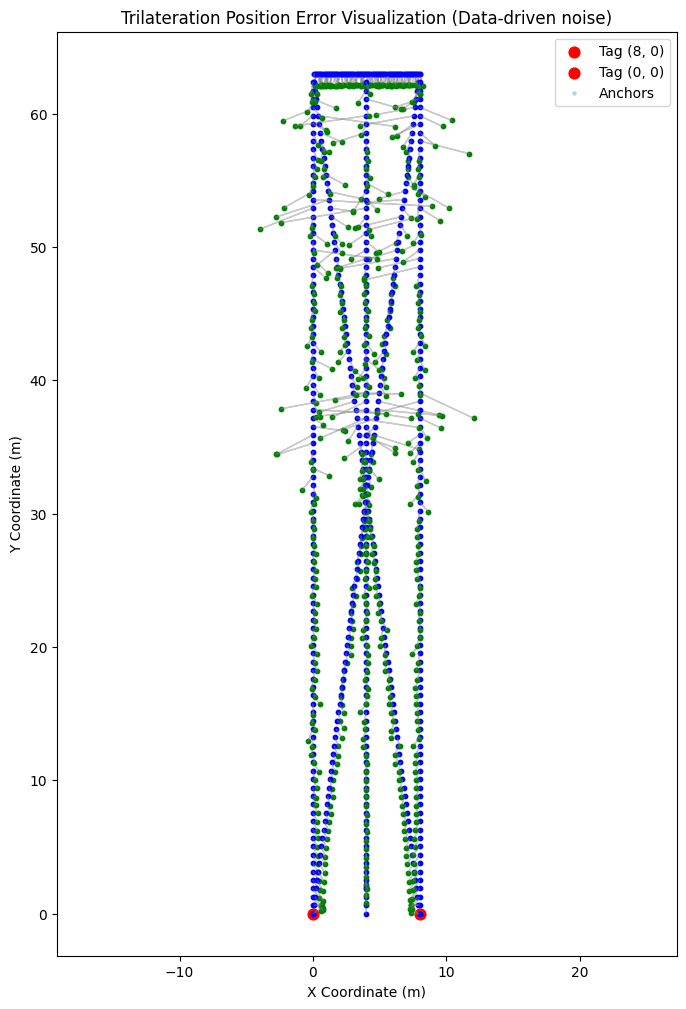

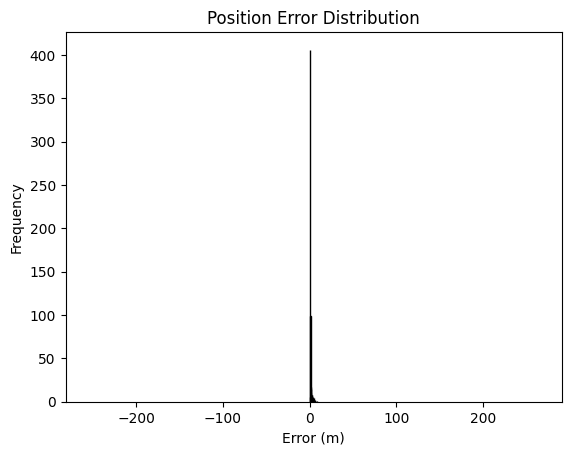

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_std_for_distance(distance, std_df):
    idx = (std_df["Real Length"] - distance).abs().idxmin()
    return std_df.loc[idx, "Standard Deviation"]

def two_tag_trilateration(tag_position, anchors_position, std_csv="distance_std.csv", mean=0, sliding_window=5):
    # 讀取實際標準差資料
    std_df = pd.read_csv(std_csv)

    anchor2tag_distance = {}
    anchor2tag_distance_noisy = {}

    for tag in tag_position:
        tag_arr = np.array(tag)
        distances = np.linalg.norm(anchors_position - tag_arr, axis=1)
        noise = np.zeros(distances.shape)

        for _ in range(sliding_window if sliding_window > 0 else 1):
            # 根據每個距離取得對應的標準差，並產生對應的 Gaussian noise
            std_devs = np.array([get_std_for_distance(d, std_df) for d in distances])
            noise += np.random.normal(loc=mean, scale=std_devs)

        if sliding_window > 0:
            noise /= sliding_window  # 平均化噪音
        
        anchor2tag_distance[tag] = distances
        anchor2tag_distance_noisy[tag] = distances + noise

    plt.figure(figsize=(8, 12))
    plt.title(f"Trilateration Position Error Visualization (Data-driven noise)")
    plt.xlabel("X Coordinate (m)")
    plt.ylabel("Y Coordinate (m)")

    for tag in tag_position:
        plt.scatter(*tag, color='red', label=f'Tag {tag}', s=60)
    plt.scatter(anchors_position[:, 0], anchors_position[:, 1], color='lightblue', label='Anchors', s=5)

    tag_list = list(tag_position)
    a = np.linalg.norm(np.array(tag_list[0]) - np.array(tag_list[1]))  # tag 間距

    errors = []
    for i in range(len(anchors_position)):
        b_noisy = anchor2tag_distance_noisy[tag_list[0]][i]
        c_noisy = anchor2tag_distance_noisy[tag_list[1]][i]
        
        b_noisy = 0.9964 * b_noisy + -0.6446
        c_noisy = 0.9964 * c_noisy + -0.6446
        
        b_true = anchor2tag_distance[tag_list[0]][i]
        c_true = anchor2tag_distance[tag_list[1]][i]

        x = (a**2 - c_noisy**2 + b_noisy**2) / (2*a)
        y = np.sqrt(abs(b_noisy**2 - x**2))

        x_c = (a**2 - c_true**2 + b_true**2) / (2*a)
        y_c = np.sqrt(abs(b_true**2 - x_c**2))

        error = np.sqrt((x - x_c)**2 + (y - y_c)**2)
        errors.append(error)

        plt.scatter(x, y, color='green', s=10)    # noisy estimate
        plt.scatter(x_c, y_c, color='blue', s=10) # ground truth
        plt.arrow(x_c, y_c, x - x_c, y - y_c, color='gray', width=0.005, alpha=0.4, length_includes_head=True)
        

    plt.axis('equal')
    plt.legend()
    errors = np.array(errors)
    print(f"✅ Total points: {len(errors)}")
    print(f"📊 Mean error     = {np.mean(errors):.4f} m")
    print(f"📈 Max error      = {np.max(errors):.4f} m")
    print(f"📉 Std deviation  = {np.std(errors):.4f} m")

    plt.figure()
    plt.hist(errors, bins=30, color='purple', edgecolor='black')
    plt.title("Position Error Distribution")
    plt.xlabel("Error (m)")
    plt.ylabel("Frequency")
    plt.axis('equal')
    

    plt.show()


# 範例參數
anchors_position = []
for i in range(100):
    anchors_position.append((i*0.08, i*0.08*63/8))
    anchors_position.append((i*0.08, 63 - i*0.08*63/8))
    anchors_position.append((i*0.08, 63))
    anchors_position.append((0, 0.63*i))
    anchors_position.append((8, 0.63*i))
    anchors_position.append((4, 0.63*i))

anchors_position = np.array(anchors_position)
tags = {(0, 0), (8, 0)}

two_tag_trilateration(tags, anchors_position, std_csv="distance_std.csv", sliding_window=5)


✅ Total points: 600
📊 Mean error     = 5.6196 m
📈 Max error      = 53.7845 m
📉 Std deviation  = 9.0068 m


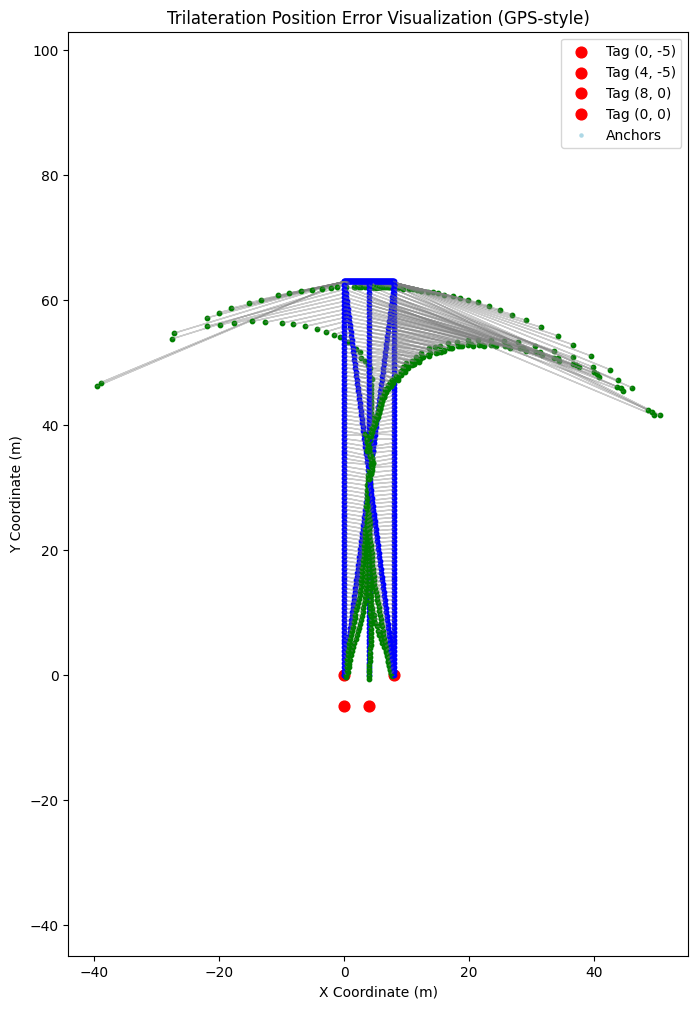

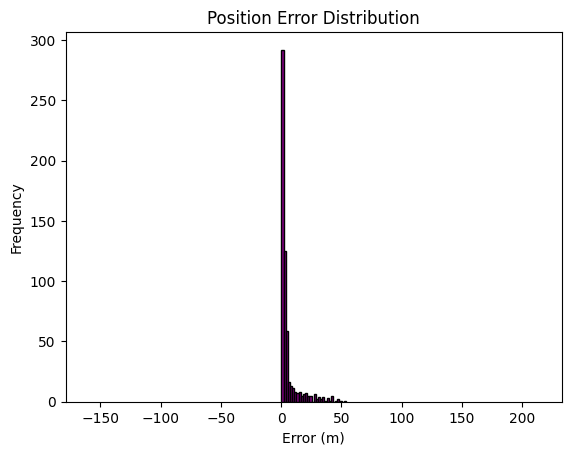

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_std_for_distance(distance, std_df):
    idx = (std_df["Real Length"] - distance).abs().idxmin()
    return std_df.loc[idx, "Standard Deviation"]

# GPS-style estimation algorithm (gradient descent)
def error_function(x, anchors, distances):
    error = 0.0
    for i in range(len(anchors)):
        dist = np.linalg.norm(x - anchors[i])
        error += (dist - distances[i]) ** 2
    return error

def gps_solve(anchors, distances, initial_guess=np.zeros(2), tol=1e-3, max_iter=100):
    x = initial_guess
    alpha = 0.01  # learning rate
    for _ in range(max_iter):
        grad = np.zeros(2)
        h = 1e-6
        for d in range(2):
            x1 = np.copy(x)
            x2 = np.copy(x)
            x1[d] += h
            x2[d] -= h
            grad[d] = (error_function(x1, anchors, distances) - error_function(x2, anchors, distances)) / (2 * h)
        x_new = x - alpha * grad
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x

def gps_style_trilateration(tag_position, anchors_position, std_csv="distance_std.csv", mean=0, sliding_window=5):
    std_df = pd.read_csv(std_csv)

    tag_list = list(tag_position)
    tag_array = [np.array(tag) for tag in tag_list]

    plt.figure(figsize=(8, 12))
    plt.title(f"Trilateration Position Error Visualization (GPS-style)")
    plt.xlabel("X Coordinate (m)")
    plt.ylabel("Y Coordinate (m)")

    for tag in tag_list:
        plt.scatter(*tag, color='red', label=f'Tag {tag}', s=60)
    plt.scatter(anchors_position[:, 0], anchors_position[:, 1], color='lightblue', label='Anchors', s=5)

    errors = []
    prev_est = np.mean(tag_array, axis=0)  # 初始估計為tag中心

    for anchor in anchors_position:
        distances = np.linalg.norm(tag_array - anchor, axis=1)  # true distances
        noise = np.zeros_like(distances)

        for _ in range(sliding_window if sliding_window > 0 else 1):
            std_devs = np.array([get_std_for_distance(d, std_df) for d in distances])
            noise += np.random.normal(loc=mean, scale=std_devs)

        if sliding_window > 0:
            noise /= sliding_window

        noisy_distances = distances + noise
        calibrated_distances = 0.9964  * noisy_distances -0.6446

        est = gps_solve(tag_array, calibrated_distances, initial_guess=prev_est)
        
        error = np.linalg.norm(est - anchor)

        errors.append(error)

        plt.scatter(*est, color='green', s=10)  # estimated position
        plt.scatter(*anchor, color='blue', s=10)  # true anchor position
        plt.arrow(anchor[0], anchor[1], est[0] - anchor[0], est[1] - anchor[1], 
                  color='gray', width=0.005, alpha=0.4, length_includes_head=True)
        
        prev_est = est  # update initial guess
    plt.axis('equal')
    plt.legend()
    errors = np.array(errors)
    print(f"✅ Total points: {len(errors)}")
    print(f"📊 Mean error     = {np.mean(errors):.4f} m")
    print(f"📈 Max error      = {np.max(errors):.4f} m")
    print(f"📉 Std deviation  = {np.std(errors):.4f} m")

    plt.figure()
    plt.hist(errors, bins=30, color='purple', edgecolor='black')
    plt.title("Position Error Distribution")
    plt.xlabel("Error (m)")
    plt.ylabel("Frequency")
    plt.axis('equal')
    plt.show()



tags = {(0, 0), (8, 0), (4,-5), (0, -5), (8,0)}



anchors_position = []
for i in range(100):
    anchors_position.append((i*0.08, i*0.08*63/8))
    anchors_position.append((i*0.08, 63 - i*0.08*63/8))
    anchors_position.append((i*0.08, 63))
    anchors_position.append((0, 0.63*i))
    anchors_position.append((8, 0.63*i))
    anchors_position.append((4, 0.63*i))

    
anchors_position = np.array(anchors_position)
gps_style_trilateration(tags, anchors_position, std_csv="distance_std.csv", sliding_window=5)




# Test if the algo actually works

✅ Total points: 700
📊 Mean error     = 0.5364 m
📈 Max error      = 14.2309 m
📉 Std deviation  = 1.2905 m
----------------------------
✅ Total points: 700
📊 Mean error     = 0.4970 m
📈 Max error      = 13.2942 m
📉 Std deviation  = 1.1686 m


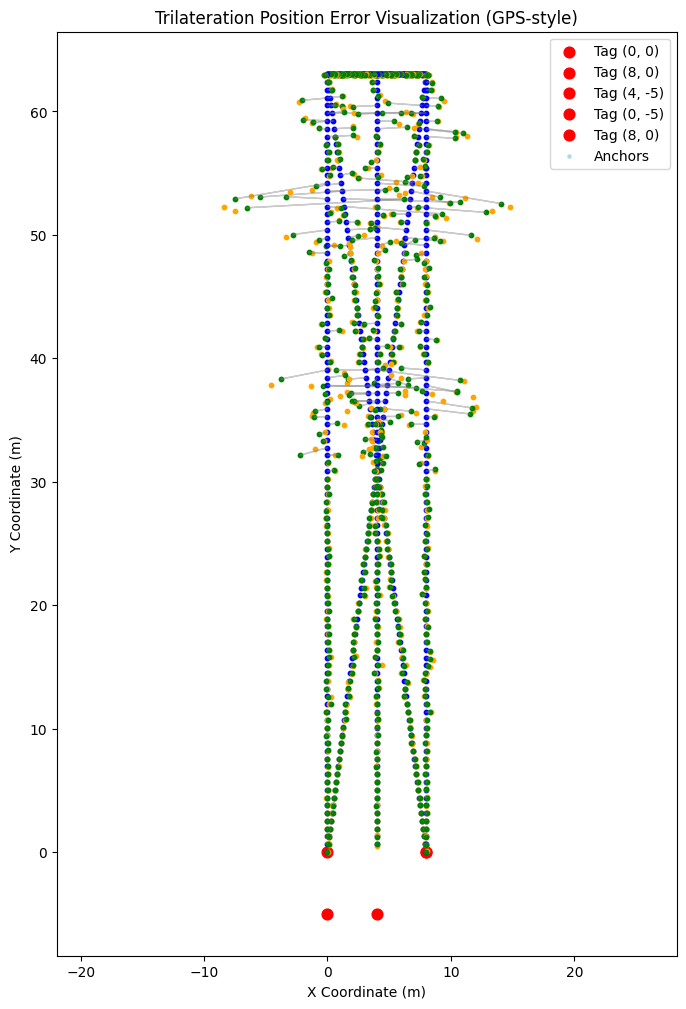

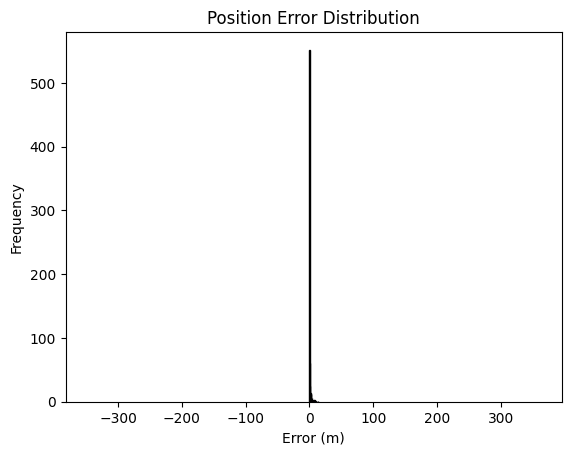

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_std_for_distance(distance, std_df):
    idx = (std_df["Real Length"] - distance).abs().idxmin()
    return std_df.loc[idx, "Standard Deviation"]

# GPS-style estimation algorithm (gradient descent)
def error_function(x, anchors, distances):
    error = 0.0
    for i in range(len(anchors)):
        dist = np.linalg.norm(x - anchors[i])
        error += (dist - distances[i]) ** 2
    return error

def two_tag_trilateration(a, b_noisy, c_noisy):
    x = (a**2 - c_noisy**2 + b_noisy**2) / (2*a)
    y = np.sqrt(abs(b_noisy**2 - x**2))
    return x, y

def gps_solve(anchors, distances, initial_guess, tol=1e-6, max_iter=500):
    x = initial_guess
    alpha = 0.01  # learning rate
    for _ in range(max_iter):
        grad = np.zeros(2)
        h = 1e-6
        for d in range(2):
            x1 = np.copy(x)
            x2 = np.copy(x)
            x1[d] += h
            x2[d] -= h
            grad[d] = (error_function(x1, anchors, distances) - error_function(x2, anchors, distances)) / (2 * h)
        x_new = x - alpha * grad
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x

def gps_style_trilateration(tag_position, anchors_position, std_csv="distance_std.csv", mean=0, sliding_window=5):
    std_df = pd.read_csv(std_csv)

    tag_list = list(tag_position)
    tag_array = [np.array(tag) for tag in tag_list]

    plt.figure(figsize=(8, 12))
    plt.title(f"Trilateration Position Error Visualization (GPS-style)")
    plt.xlabel("X Coordinate (m)")
    plt.ylabel("Y Coordinate (m)")

    for tag in tag_list:
        plt.scatter(*tag, color='red', label=f'Tag {tag}', s=60)
    plt.scatter(anchors_position[:, 0], anchors_position[:, 1], color='lightblue', label='Anchors', s=5)

    errors = []
    error2s=[]
    prev_est = np.mean(tag_array, axis=0)  # 初始估計為tag中心

    for anchor in anchors_position:
        distances = np.linalg.norm(tag_array - anchor, axis=1)  # true distances
        noise = np.zeros_like(distances)

        for _ in range(sliding_window if sliding_window > 0 else 1):
            std_devs = np.array([get_std_for_distance(d, std_df) for d in distances])
            noise += np.random.normal(loc=mean, scale=std_devs)

        if sliding_window > 0:
            noise /= sliding_window

        noisy_distances = distances + noise
        # calibrated_distances = 0.9964  * noisy_distances -0.6446
        
        x, y = two_tag_trilateration(np.linalg.norm(np.array(tag_list[0]) - np.array(tag_list[1])), noisy_distances[0], noisy_distances[1])

        est = gps_solve(tag_array, noisy_distances, (x, y))
        
        error = np.linalg.norm(est - anchor)
        error2= np.linalg.norm(np.array([x, y]) - anchor)

        errors.append(error)
        error2s.append(error2)
        
        plt.scatter(*anchor, color='blue', s=10)
        plt.scatter(x, y, color='orange', s=10)    # noisy estimate
        plt.scatter(*est, color='green', s=10)  # estimated position
          # true anchor position
        plt.arrow(anchor[0], anchor[1], est[0] - anchor[0], est[1] - anchor[1], 
                  color='gray', width=0.005, alpha=0.4, length_includes_head=True)
        
        
    plt.axis('equal')
    plt.legend()
    errors = np.array(errors)
    error2s = np.array(error2s)
    print(f"✅ Total points: {len(error2s)}")
    print(f"📊 Mean error     = {np.mean(error2s):.4f} m")
    print(f"📈 Max error      = {np.max(error2s):.4f} m")
    print(f"📉 Std deviation  = {np.std(error2s):.4f} m")
    print (f"----------------------------")
    print(f"✅ Total points: {len(errors)}")
    print(f"📊 Mean error     = {np.mean(errors):.4f} m")
    print(f"📈 Max error      = {np.max(errors):.4f} m")
    print(f"📉 Std deviation  = {np.std(errors):.4f} m")

    plt.figure()
    plt.hist(errors, bins=30, color='purple', edgecolor='black')
    plt.title("Position Error Distribution")
    plt.xlabel("Error (m)")
    plt.ylabel("Frequency")
    plt.axis('equal')
    plt.show()



tags = [(0, 0), (8, 0), (4,-5), (0, -5), (8,0)]



anchors_position = []
for i in range(100):
    x = i * 0.08
    y_diag = x * (63 / 8)          # 對角線
    anchors_position.append((x, y_diag))

# 水平線上緣
for i in range(100):
    x = 8 - i * 0.08
    anchors_position.append((x, 63))

# 斜線部分：對角線與反對角線
for i in range(100):
    x = i * 0.08
    y_anti = 63 - x * (63 / 8)     # 反對角線
    anchors_position.append((x, y_anti))

# 垂直線：左、中、右
for i in range(100):
    y = i * 0.63
    anchors_position.append((8, y))
# 水平線上緣
for i in range(100):
    x = 8 - i * 0.08
    anchors_position.append((x, 63))

# 垂直線：左、中、右
for i in range(100):
    y =63 - i * 0.63
    anchors_position.append((0, y))
    
for i in range(100):
    y =63 - i * 0.63
    anchors_position.append((4, y))

    
anchors_position = np.array(anchors_position)
gps_style_trilateration(tags, anchors_position, std_csv="distance_std.csv", sliding_window=5)


